# 06 — Valeur économique : que rapporte vraiment un modèle à HEC Match ?

`05_performance.ipynb` (Blanquette) calcule le P&L de chaque modèle à son seuil optimal. Ce notebook répond à la
question que posera le jury : **le modèle rapporte-t-il plus qu'une stratégie sans modèle ?**

1. Comparaison aux stratégies naïves (montrer tout le monde, personne, oracle), avec intervalles de confiance.
2. Pourquoi « montrer tout le monde » est si difficile à battre : le **seuil de rentabilité**.
3. **Sensibilité** : pour quelles hypothèses de coûts le modèle crée-t-il de la valeur ?
4. **Contrainte de capacité** : une vraie app ne montre que k profils par utilisateur. Le modèle sert alors à *classer*.

Hypothèses de coûts : celles du groupe (`data/economic_assumptions.json`) : **+X** € par profil montré qui reçoit un oui,
**−Y** € par profil montré qui reçoit un non, **−Z** € par oui manqué (profil caché qui aurait plu).
Incertitude : **bootstrap apparié des 6 sessions de test** (2 000 tirages), même logique que la stabilité de Rémi.
Code : `src/economics.py` ; sorties : `reports/economics/`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.economics import *

pd.set_option("display.max_colwidth", 60)
OUT_DIR.mkdir(parents=True, exist_ok=True)
summary = {}

ctx = load_context()
test, X, Y, Z, thresholds = ctx["test"], ctx["X"], ctx["Y"], ctx["Z"], ctx["thresholds"]
p_star = break_even(X, Y, Z)
summary["hypotheses"] = {"X": X, "Y": Y, "Z": Z, "seuil_rentabilite_p_star": round(p_star, 3),
                         "taux_oui_test": round(test.dec.mean(), 3), "n_test": len(test)}
summary["hypotheses"]

{'X': 2,
 'Y': 1,
 'Z': 1,
 'seuil_rentabilite_p_star': 0.25,
 'taux_oui_test': np.float64(0.429),
 'n_test': 1826}

## 1. Les modèles battent-ils « montrer tout le monde » ?

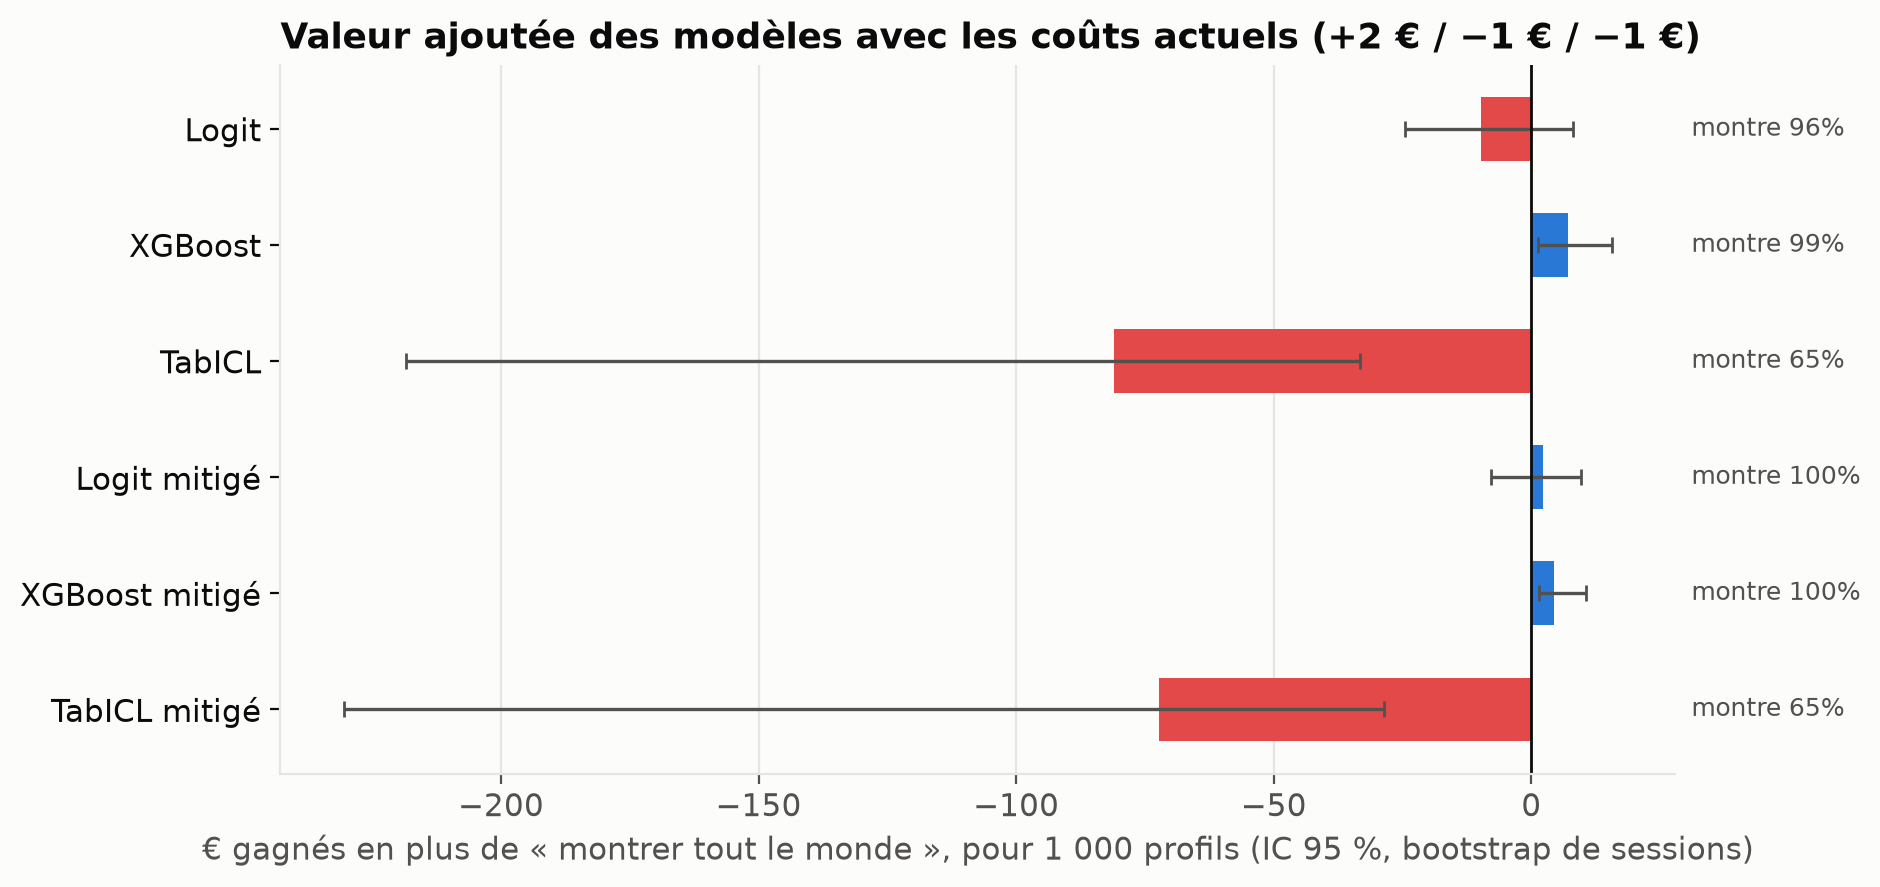

,strategie,seuil,part_montree,pnl_test,pnl_pour_1000,vs_montrer_tout_pour_1000,ic_bas,ic_haut
0,Montrer tout le monde,NaN,1.00,523.0,286.42,0.00,NaN,NaN
1,Ne montrer personne,NaN,0.00,-783.0,-428.81,-715.22,NaN,NaN
2,Oracle (parfait),NaN,0.43,1566.0,857.61,571.19,NaN,NaN
3,Logit — seuil optimisé (CV train),0.10,0.96,505.0,276.56,-9.86,-24.60,8.09
4,Logit — règle p > p*,0.25,0.77,401.0,219.61,-66.81,-123.19,-31.37
5,XGBoost — seuil optimisé (CV train),0.10,0.99,536.0,293.54,7.12,1.29,15.67
6,XGBoost — règle p > p*,0.25,0.81,500.0,273.82,-12.60,-68.54,50.03
7,TabICL — seuil optimisé (CV train),0.35,0.65,375.0,205.37,-81.05,-218.49,-33.18
8,TabICL — règle p > p*,0.25,0.86,535.0,292.99,6.57,-83.33,39.74
9,Logit mitigé — seuil optimisé (CV train),0.05,1.00,527.0,288.61,2.19,-7.91,9.57


In [2]:
table = policy_table(test, X, Y, Z, thresholds)
table.to_csv(OUT_DIR / "strategies_vs_montrer_tout.csv", index=False)
display(Image(plot_policy_bars(table, X, Y, Z)))
table[["strategie", "seuil", "part_montree", "pnl_test", "pnl_pour_1000",
       "vs_montrer_tout_pour_1000", "ic_bas", "ic_haut"]].round(2)

In [3]:
naive = table.set_index("strategie")
best = table[table.strategie.str.contains("seuil optimisé")].sort_values("vs_montrer_tout_pour_1000").iloc[-1]
summary["strategies_naives_pour_1000"] = {k: round(naive.loc[k, "pnl_pour_1000"], 1)
                                         for k in ["Montrer tout le monde", "Ne montrer personne", "Oracle (parfait)"]}
summary["meilleur_modele_vs_montrer_tout"] = {"strategie": best.strategie,
                                             "gain_pour_1000": round(best.vs_montrer_tout_pour_1000, 1),
                                             "ic": [round(best.ic_bas, 1), round(best.ic_haut, 1)]}
summary["meilleur_modele_vs_montrer_tout"]

{'strategie': 'XGBoost — seuil optimisé (CV train)',
 'gain_pour_1000': np.float64(7.1),
 'ic': [np.float64(1.3), np.float64(15.7)]}

**Lecture.** Montrer tout le monde rapporte environ **286 € pour 1 000 profils** ; un oracle parfait, 858 €.
Les meilleurs modèles (XGBoost, base ou mitigé, au seuil optimisé par validation croisée) ne font que **+4 à +7 €**
de mieux (gain significatif mais minuscule), en montrant 99 à 100 % des profils. Le logit fait jeu égal.

**TabICL perd environ 75 € pour 1 000 profils, mais c'est un artefact de méthode, pas du modèle** : son seuil (0,35)
a été choisi sur ses prédictions du train, qu'il a vues en contexte (AUC 0,92 sur le train contre 0,63 en test).
Le P&L simulé y était de 751 au lieu d'environ 290 en réalité, ce qui pousse à un seuil trop sélectif. Avec la
règle théorique ci-dessous, TabICL fait jeu égal avec les autres. *(À corriger dans `05_performance` : choisir le
seuil de TabICL avec la règle théorique, ou le signaler comme limite.)*

## 2. Pourquoi est-ce si difficile ? Le seuil de rentabilité

Montrer un profil de probabilité de oui *p* rapporte en espérance `p·X − (1−p)·Y` ; le cacher coûte `p·Z` (oui manqué).
Montrer est donc rentable dès que **p > p\* = Y / (X + Y + Z)**. Avec +2 / −1 / −1 : **p\* = 25 %**.

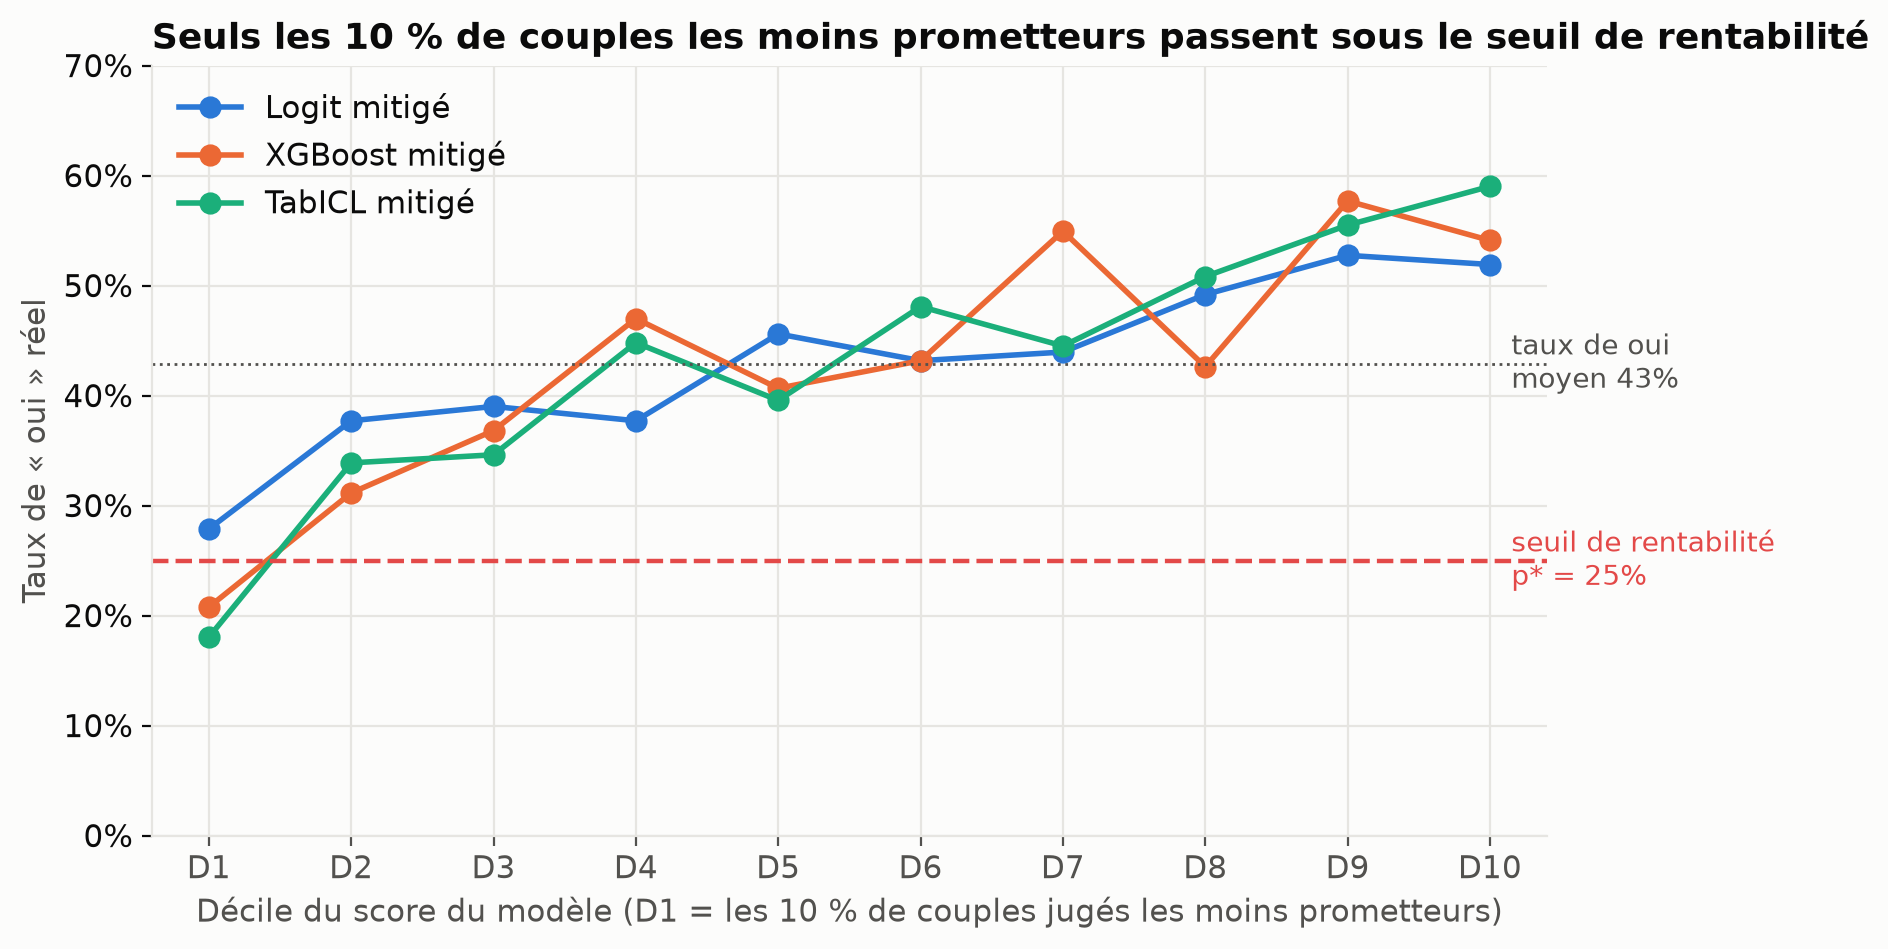

,1,2,3,4,5,6,7,8,9,10
logit_mitigated,27.9,37.7,39.0,37.7,45.6,43.2,44.0,49.2,52.7,51.9
xgb_mitigated,20.8,31.1,36.8,47.0,40.7,43.2,54.9,42.6,57.7,54.1
tabicl_mitigated,18.0,33.9,34.6,44.8,39.6,48.1,44.5,50.8,55.5,59.0


In [4]:
rates = yes_rate_by_decile(test)
rates.to_csv(OUT_DIR / "taux_oui_par_decile.csv")
display(Image(plot_break_even(rates, p_star, test.dec.mean())))
(rates * 100).round(1).T

**Lecture.** Le taux de oui moyen (43 %) est bien au-dessus de 25 %. Même en triant les couples par le score du
modèle, **seul le premier décile** (les 10 % jugés les moins prometteurs) passe sous le seuil pour XGBoost et TabICL,
et aucun pour le logit. Le mieux qu'un modèle puisse faire est donc de masquer ces ~10 % de profils : c'est
précisément ce que fait le seuil optimisé de XGBoost, d'où son petit gain.

**Ce n'est pas un échec des modèles, c'est l'économie du problème** : quand un oui rapporte deux fois plus qu'un non
ne coûte et que 43 % des rencontres finissent en oui, il vaut mieux presque tout montrer.

## 3. Sensibilité : quand le modèle crée-t-il de la valeur ?

On fait varier Y, le coût d'une mauvaise recommandation (frustration, désabonnement), à X = 2 € et Z = 1 € fixés.
Règle de décision : montrer si p > p\*(Y), **sans aucun réglage sur le test**. On compare à la *meilleure* stratégie
naïve (tout montrer ou ne rien montrer, selon ce qui rapporte le plus).

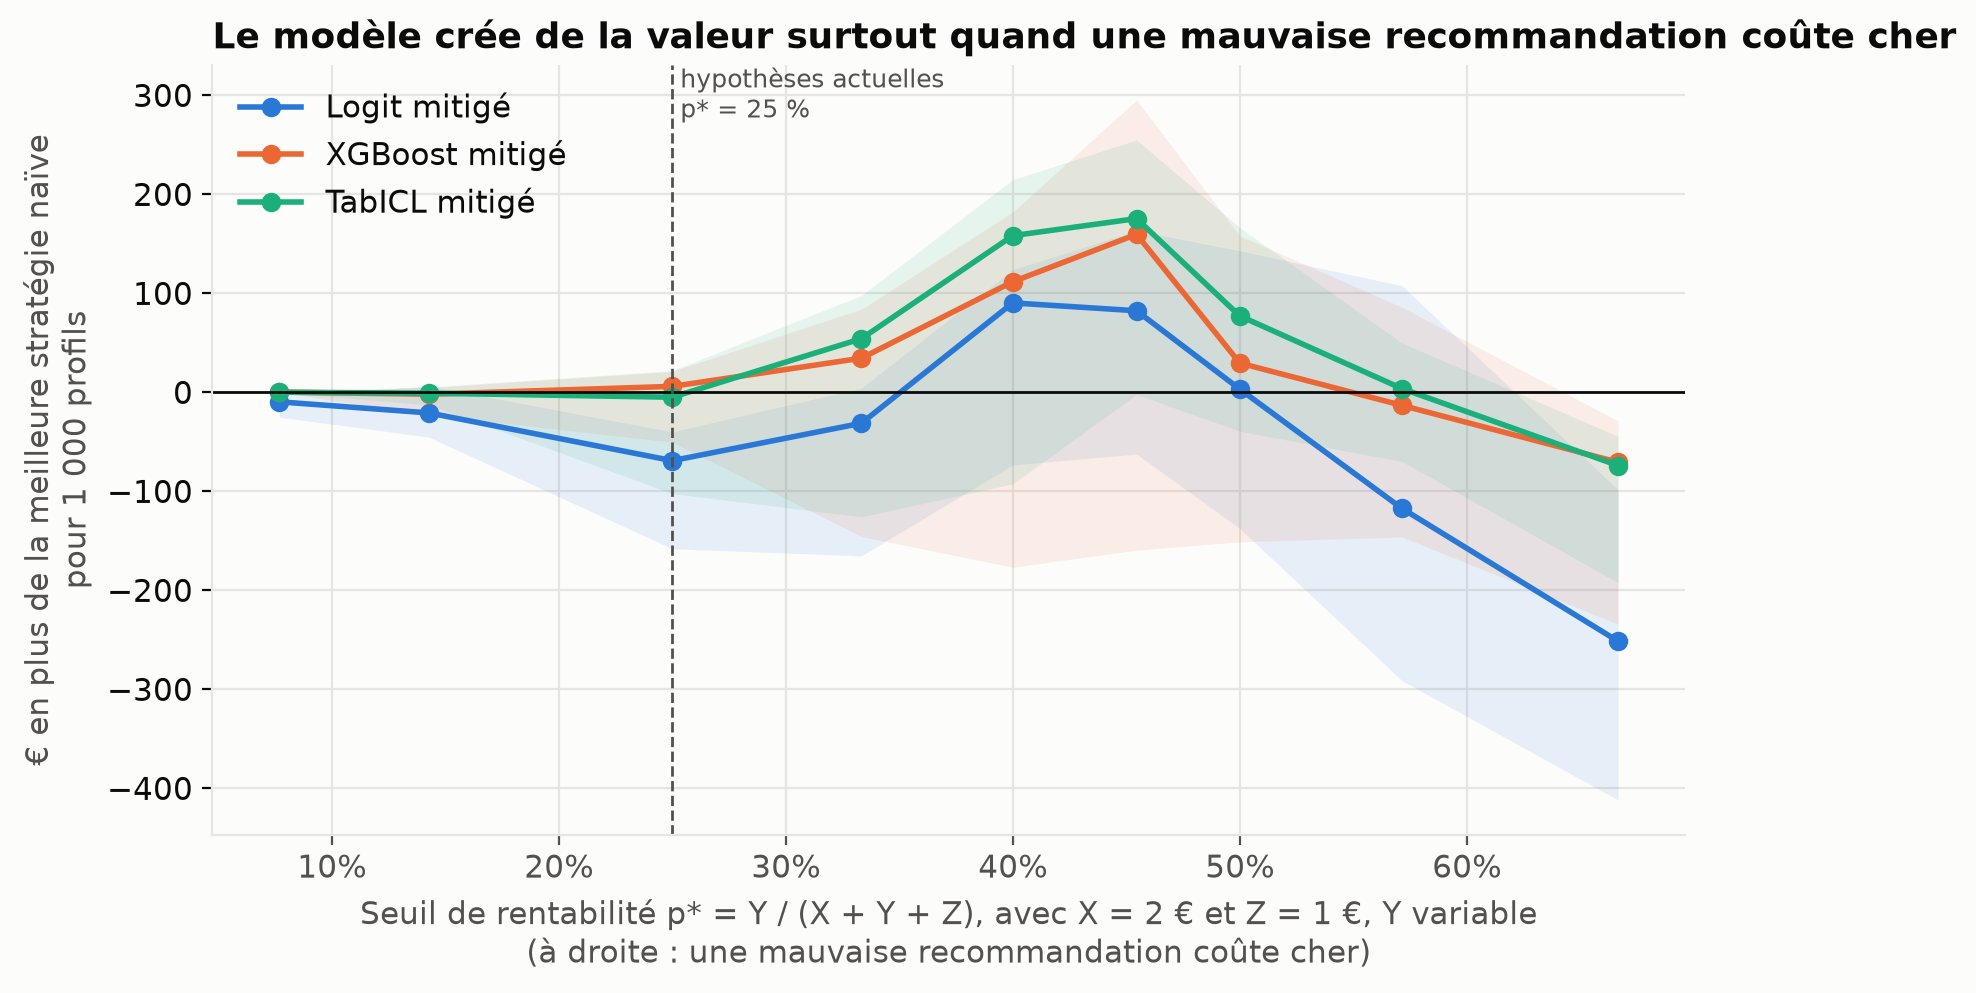

,model,logit_mitigated,tabicl_mitigated,xgb_mitigated
Y,p_star,,,
0.25,0.076923,-9.6,0.1,0.3
0.50,0.142857,-20.8,-0.8,-1.9
1.00,0.250000,-69.0,-4.9,6.0
1.50,0.333333,-31.2,54.2,34.5
2.00,0.400000,90.4,158.3,111.7
2.50,0.454545,82.4,175.5,159.6
3.00,0.500000,3.3,77.2,29.6
4.00,0.571429,-117.2,3.8,-13.1
6.00,0.666667,-251.4,-73.9,-70.6


In [5]:
sens = cost_sensitivity(test, X, Z)
sens.to_csv(OUT_DIR / "sensibilite_cout_mauvaise_reco.csv", index=False)
display(Image(plot_cost_sensitivity(sens, X, Y, Z)))
peak = sens.loc[sens.valeur_ajoutee_pour_1000.idxmax()]
summary["sensibilite_pic"] = {"Y": peak.Y, "p_star": round(peak.p_star, 3), "modele": NAMES[peak.model],
                              "gain_pour_1000": round(peak.valeur_ajoutee_pour_1000, 1),
                              "ic": [round(peak.ic_bas, 1), round(peak.ic_haut, 1)]}
sens.pivot(index=["Y", "p_star"], columns="model", values="valeur_ajoutee_pour_1000").round(1)

**Lecture.** La valeur du modèle a une forme en cloche :

- **Mauvaise recommandation peu coûteuse** (p\* bas, à gauche) : il faut tout montrer, le modèle n'apporte rien.
- **Mauvaise recommandation aussi coûteuse qu'un bon match rapporte** (p\* ≈ 40–45 %, proche du taux de oui moyen) :
  c'est là que la décision est la plus incertaine, et le modèle rapporte jusqu'à **+150 à +175 € pour 1 000 profils**
  (TabICL et XGBoost mitigés).
- **Mauvaise recommandation très coûteuse** (p\* élevé, à droite) : il faut ne presque rien montrer ; nos modèles,
  trop confiants (ils prédisent de 15 % à 75 % quand la réalité va de 26 % à 56 %), montrent encore trop.

Les intervalles sont larges (6 sessions de test seulement) : la forme est nette, les niveaux sont indicatifs.
**Message pour HEC Match : la valeur du modèle dépend moins de l'algorithme que du coût réel d'une mauvaise
recommandation. C'est la première chose à mesurer (A/B test sur le désabonnement).**

## 4. Contrainte de capacité : l'app ne montre que k profils par utilisateur

Dans une vraie app, on ne peut pas tout montrer : chaque utilisateur voit quelques profils par jour. La question
devient : **parmi les candidats d'un utilisateur, lesquels montrer en premier ?** Le modèle sert à *classer*.
Mesure : part de oui parmi les k profils montrés (précision@k), comparée au hasard et à un oracle.
Ici, chaque utilisateur (A) choisit parmi les 5 à 20 personnes rencontrées dans sa session.

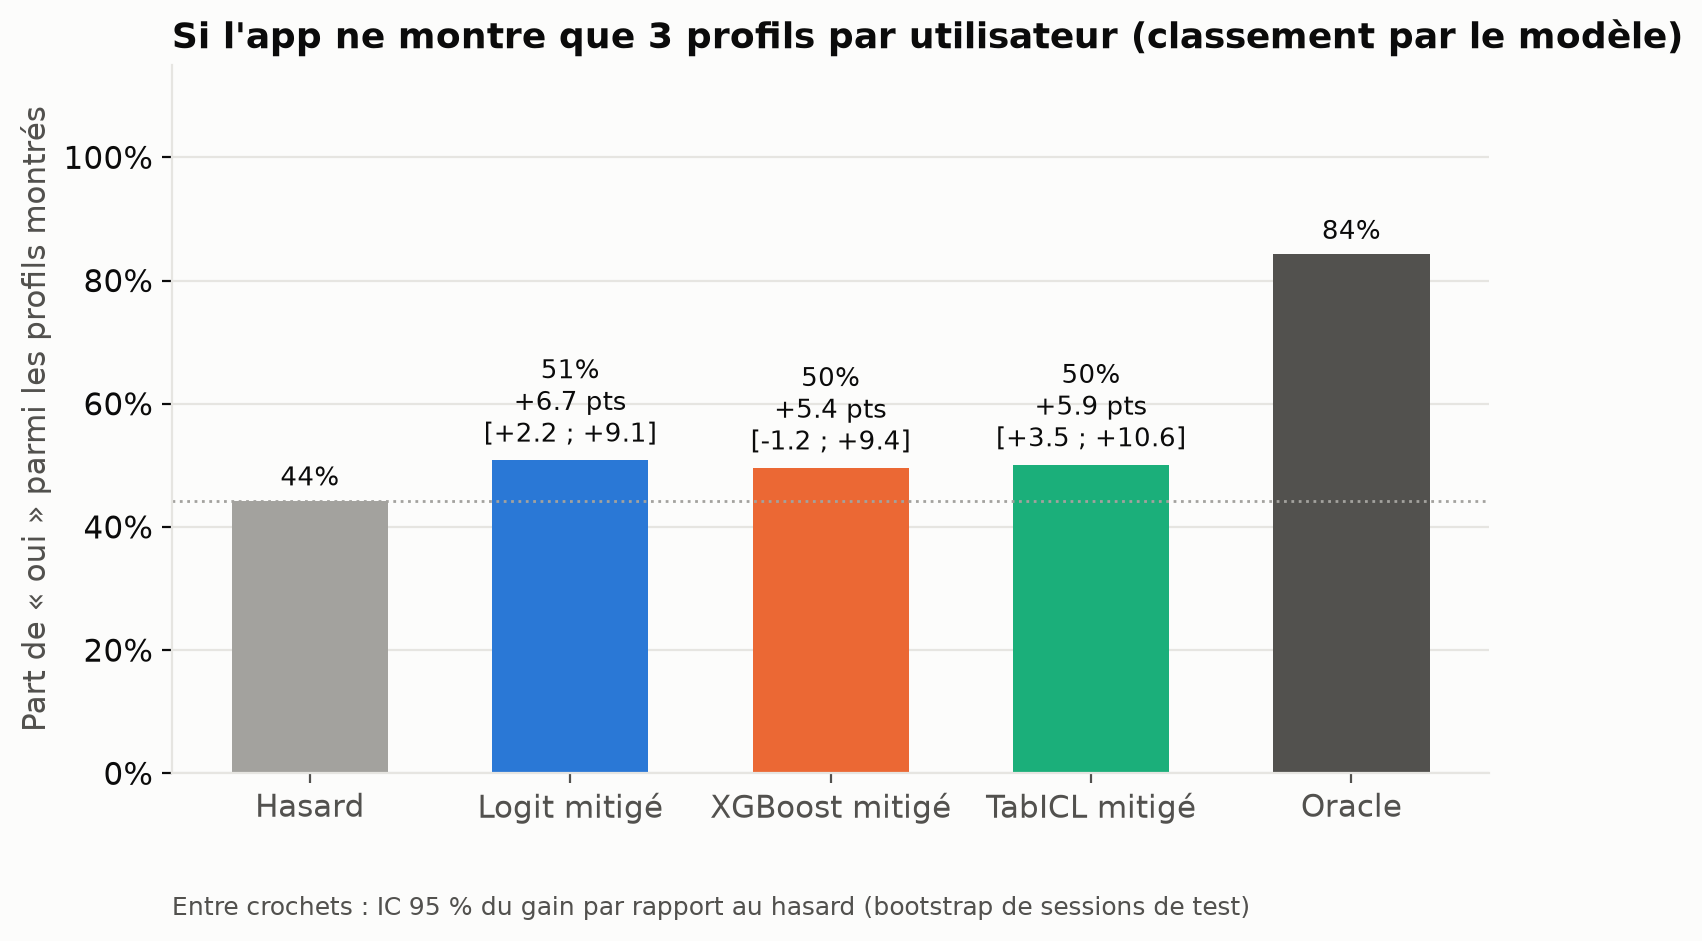

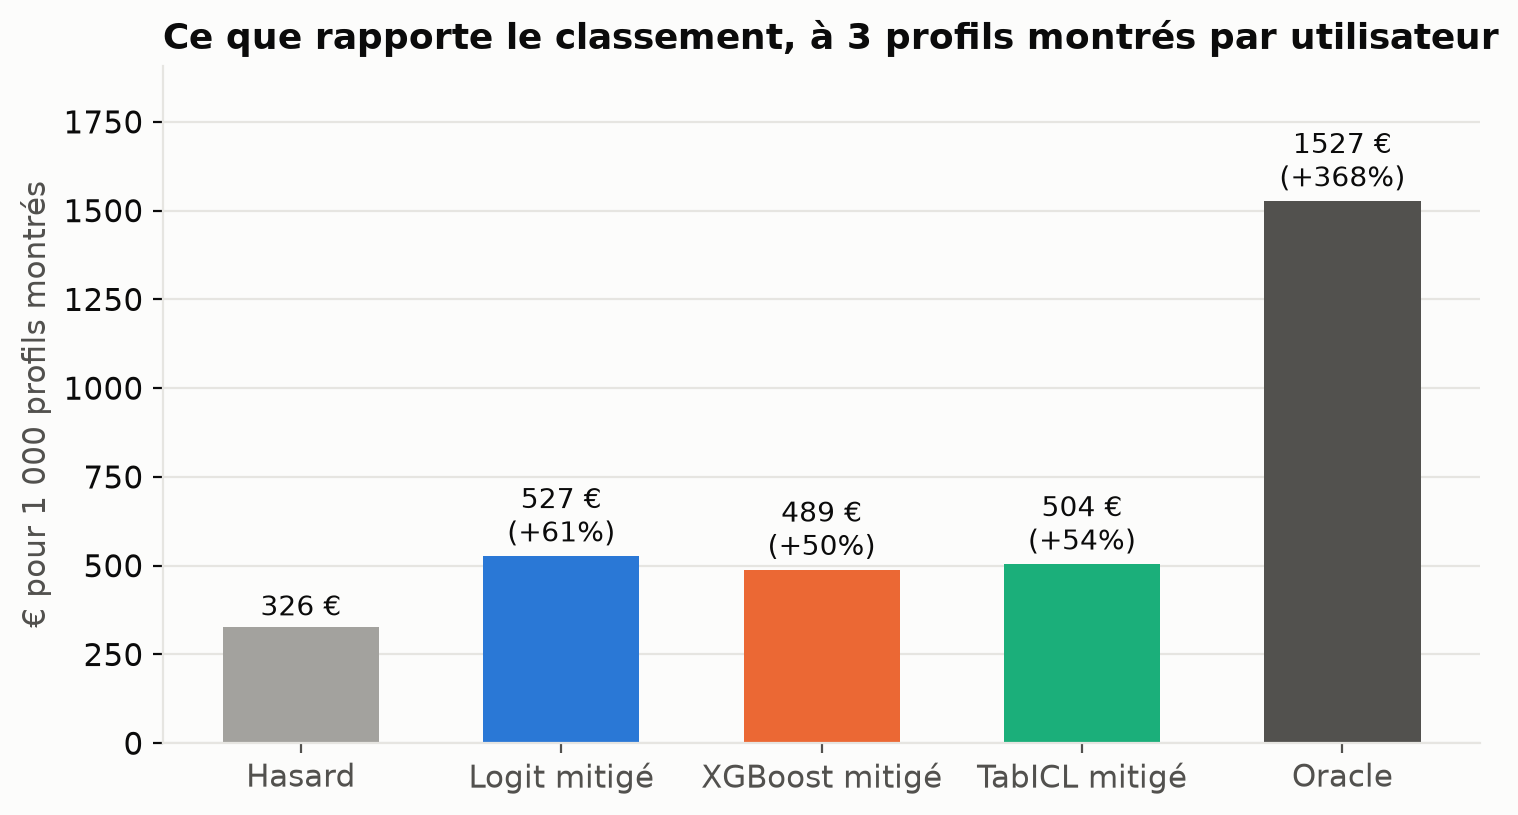

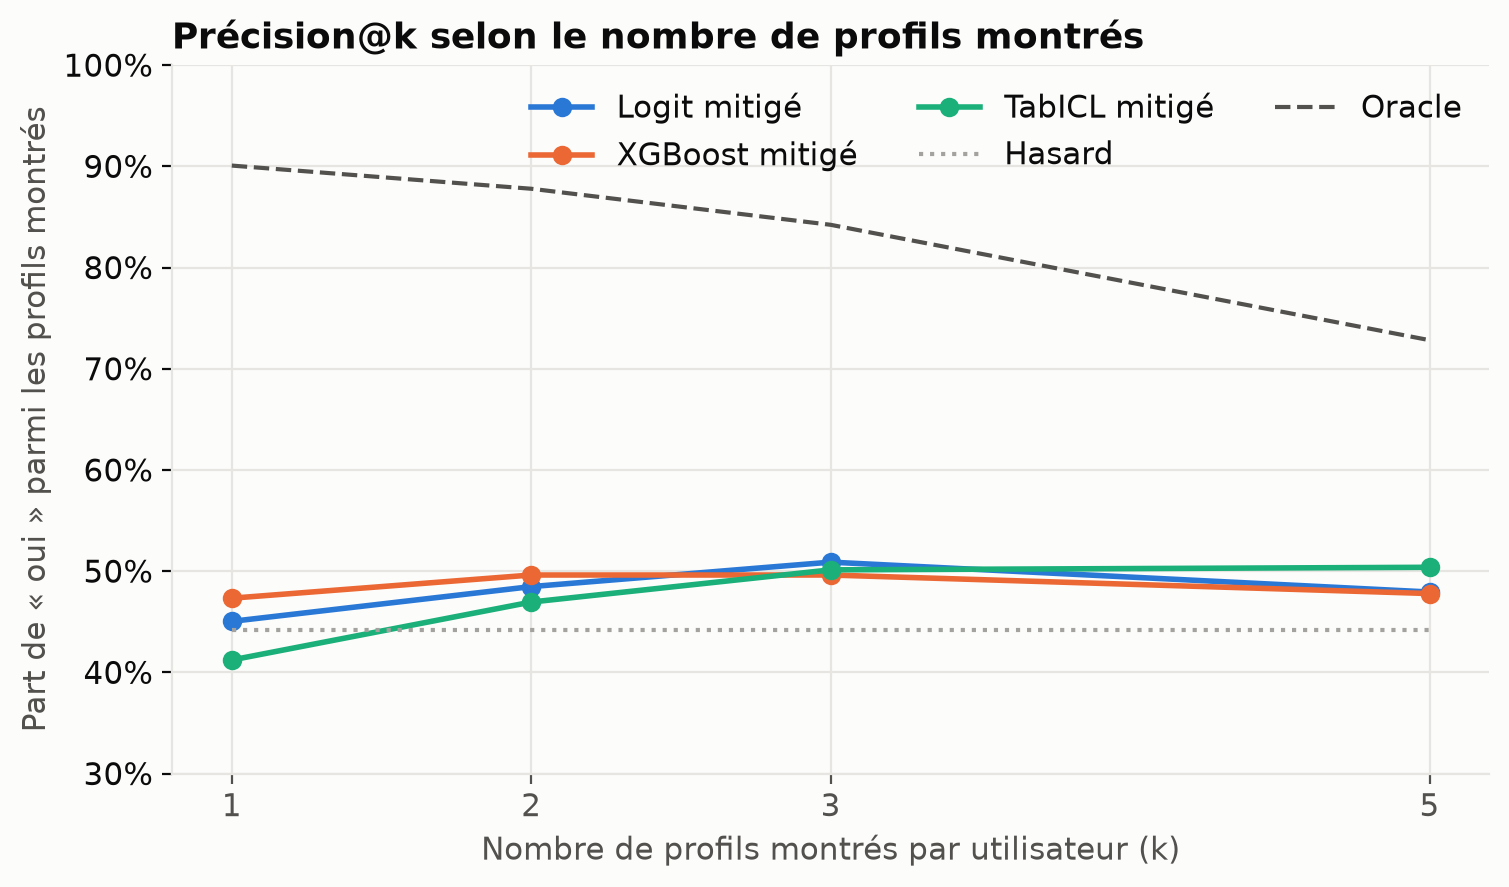

AUC intra-utilisateur (qualité du classement des candidats de chaque utilisateur) : {'Logit': 0.59, 'XGBoost': 0.573, 'TabICL': 0.605, 'Logit mitigé': 0.569, 'XGBoost mitigé': 0.578, 'TabICL mitigé': 0.622}


,k,strategie,precision,gain_vs_hasard_pp,ic_bas,ic_haut,eur_pour_1000_montres,gain_eur_pour_1000_vs_hasard,gain_eur_ic_bas,gain_eur_ic_haut
16,3,Hasard,0.442,0.000,NaN,NaN,326.225,0.000,NaN,NaN
17,3,Oracle,0.842,40.016,NaN,NaN,1526.718,1200.492,NaN,NaN
18,3,Logit,0.519,7.701,3.879,11.458,557.252,231.027,116.369,343.750
19,3,XGBoost,0.491,4.902,1.152,8.452,473.282,147.057,34.549,253.571
20,3,TabICL,0.471,2.866,-0.060,5.825,412.214,85.988,-1.794,174.740
21,3,Logit mitigé,0.509,6.683,2.202,9.125,526.718,200.492,66.071,273.756
22,3,XGBoost mitigé,0.496,5.411,-1.159,9.388,488.550,162.324,-34.758,281.641
23,3,TabICL mitigé,0.501,5.920,3.488,10.604,503.817,177.591,104.627,318.125


In [6]:
topk = topk_table(test, X, Y)
topk.to_csv(OUT_DIR / "top_k_par_utilisateur.csv", index=False)
display(Image(plot_topk(topk, 3)))
display(Image(plot_topk_euros(topk, 3)))
display(Image(plot_topk_curve(topk)))
auc_in = {NAMES[m]: round(within_user_auc(test, f"proba_{m}"), 3) for m in MODELS}
summary["top3"] = topk[topk.k == 3].set_index("strategie")[
    ["precision", "gain_vs_hasard_pp", "ic_bas", "ic_haut", "eur_pour_1000_montres"]].round(3).to_dict("index")
summary["auc_intra_utilisateur"] = auc_in
print("AUC intra-utilisateur (qualité du classement des candidats de chaque utilisateur) :", auc_in)
topk[topk.k == 3].round(3)

**Lecture.** Avec 3 profils par utilisateur, les modèles mitigés font passer la part de oui de **44 % (hasard) à
50–51 %**, soit **+5 à +7 points** (significatif pour le logit et TabICL mitigés, à la limite pour XGBoost).
En euros, pour 1 000 profils montrés : environ **+50 à +60 %** par rapport au hasard (≈ 500 € contre 326 €).
Sous contrainte de capacité, **c'est là que le modèle crée de la valeur**.

Deux nuances importantes :

- **Les trois modèles font jeu égal** : les intervalles se chevauchent largement, et le logit (white box) classe
  aussi bien que les boîtes noires.
- **On reste loin de l'oracle** (84 %) : le modèle ne capte qu'environ un sixième du gain possible. Cohérent avec
  l'interprétabilité : pour classer les candidats *d'un même utilisateur*, les variables de A ne servent plus à rien ;
  il ne reste que celles de B et du couple, qui ne pèsent qu'environ 48 % de l'importance.

## 5. Synthèse — messages pour la soutenance

In [7]:
(OUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False, default=float))
print(json.dumps(summary, indent=2, ensure_ascii=False, default=float)[:3000])

{
  "hypotheses": {
    "X": 2,
    "Y": 1,
    "Z": 1,
    "seuil_rentabilite_p_star": 0.25,
    "taux_oui_test": 0.429,
    "n_test": 1826
  },
  "strategies_naives_pour_1000": {
    "Montrer tout le monde": 286.4,
    "Ne montrer personne": -428.8,
    "Oracle (parfait)": 857.6
  },
  "meilleur_modele_vs_montrer_tout": {
    "strategie": "XGBoost — seuil optimisé (CV train)",
    "gain_pour_1000": 7.1,
    "ic": [
      1.3,
      15.7
    ]
  },
  "sensibilite_pic": {
    "Y": 2.5,
    "p_star": 0.455,
    "modele": "TabICL mitigé",
    "gain_pour_1000": 175.5,
    "ic": [
      -2.1,
      254.9
    ]
  },
  "top3": {
    "Hasard": {
      "precision": 0.442,
      "gain_vs_hasard_pp": 0.0,
      "ic_bas": NaN,
      "ic_haut": NaN,
      "eur_pour_1000_montres": 326.225
    },
    "Oracle": {
      "precision": 0.842,
      "gain_vs_hasard_pp": 40.016,
      "ic_bas": NaN,
      "ic_haut": NaN,
      "eur_pour_1000_montres": 1526.718
    },
    "Logit": {
      "precision": 0.519

1. **Avec nos hypothèses, montrer tout le monde est quasi optimal** (286 € pour 1 000 profils) : le seuil de
   rentabilité (25 %) est loin sous le taux de oui moyen (43 %). Les modèles n'y ajoutent que +4 à +7 €.
2. **La valeur d'un modèle dépend du coût d'une mauvaise recommandation** : elle culmine (+150 à +175 € pour
   1 000 profils) quand ce coût rend la décision la plus incertaine. À mesurer avant de choisir un algorithme.
3. **Dans une vraie app (k profils par jour), le modèle sert à classer** : +5 à +7 points de oui parmi les profils
   montrés, soit environ +50 à +60 % de P&L par profil montré. C'est l'argument business du projet.
4. **Aucun modèle ne domine économiquement** : logit, XGBoost et TabICL mitigés font jeu égal (intervalles qui se
   chevauchent). Le choix doit donc se faire sur la fairness, l'explicabilité et la stabilité.
5. **Limites** : P&L construit sur des hypothèses (non mesurées) ; 6 sessions de test (intervalles larges) ;
   décision individuelle (`dec`) et non match réciproque ; modèles mal calibrés (trop confiants).